In [30]:
# General imports
import pandas as pd
import numpy as np
import itertools
import math
from tqdm import tqdm

# Import custom LIF SNN implementation
from LIF_SNN_network import SNNLayer

# Set random seed for reproducability
#np.random.seed(42)

**Test data**

In [31]:
df_train = pd.read_csv("CSV_results/train_spike_trains.csv")
df_test = pd.read_csv("CSV_results/test_spike_trains.csv")

spike_cols = [c for c in df_train.columns if c.startswith("spike_")]

input_spikes      = [list(map(int, row)) for row in df_train[spike_cols].values]
correct_outputs   = df_train["label"].tolist()

test_dataset         = [list(map(int, row)) for row in df_test[spike_cols].values]
test_correct_outputs = df_test["label"].tolist()

**Parameters**

In [32]:
# Input/Output size — derived from the loaded CSV (see data cell above)
# Best preprocessing config: 8×3 grid + 4 dist bits + 5 aruco bins = 33
n_inputs  = len(spike_cols)   # 33
n_outputs = 3

# Aruco position within the spike vector: grid + dist → aruco at end
# 8*3=24 grid bins + 4 dist bits = 28 → aruco at indices 28..32
aruco_start = n_inputs - 5    # = 28
n_aruco     = 5

# Training params
n_epochs = 15
n_runs = 5

# Neuron hyperparameters
decay_range = [64, 128]
threshold_range = [512, 1024]
reset_range = [0]

# Synapse parameters
lr_shift_range = [3]
initial_weight_range = [None]
t_pre_range = [3]
t_post_range = [2]
tau_e_shift_range = [3]
dw_pos_range = [32]
dw_neg_range = [32]
min_weight_range = [32]
max_weight_range = [127, 255]

# Dopamine: signed integer. Positive = reward, negative = punishment.
# delta_w = (eligibility * dopamine) >> lr_shift
dopamine_reward_range = [1]   # reward magnitude
dopamine_punish_range = [-1]  # punishment magnitude (negative)

mode_range = ['rstdp', 'stdp']

# Hidden layer: number of hidden neurons (0 = no hidden layer, matches original behaviour)
n_hidden_range = [0, 8, 16]

In [33]:
# Calculate total combinations and set up all configurations
ranges = [
    decay_range, threshold_range, reset_range,
    lr_shift_range, initial_weight_range,
    t_pre_range, t_post_range, tau_e_shift_range,
    dw_pos_range, dw_neg_range,
    min_weight_range, max_weight_range,
    dopamine_reward_range, dopamine_punish_range,
    mode_range,
    n_hidden_range,
]

# Printing the total number of configurations
total_configurations = math.prod(map(len, ranges))
print(f"Number of configurations: ", total_configurations)

Number of configurations:  48


**Logging network activity**

In [34]:
# Initialize history lists
tuning_results = []
mean_run_acc = []
epoch_acc = []
num_correct = 0

In [35]:
def parse_aruco_state(spike_row, aruco_start, n_aruco):
    aruco = spike_row[aruco_start : aruco_start + n_aruco]
    seen  = bool(any(aruco))
    if not seen:
        return False, 0
    b = int(np.argmax(aruco))
    c = n_aruco // 2
    return True, (0 if b == c else (-1 if b < c else +1))


def reward_signal(seen, pos, action_idx, dopamine_reward, dopamine_punish):
    """Returns signed dopamine integer. Zero = no-op."""
    if seen and (
        (pos == 0  and action_idx == 1) or
        (pos == -1 and action_idx == 0) or
        (pos == +1 and action_idx == 2)
    ):
        return dopamine_reward  # correct alignment action: reward

    if not seen and action_idx in (0, 2):
        return 1                # searching: weak reward

    return dopamine_punish      # everything else: punish


def build_network(n_inputs, n_hidden, n_outputs, neuron_params, synapse_params,
                  track_eligibility=False):
    """Build a list of SNNLayer objects. Hidden layer is omitted when n_hidden=0."""
    layers = []
    if n_hidden > 0:
        layers.append(SNNLayer(n_inputs=n_inputs, n_outputs=n_hidden,
                               synapse_params=synapse_params,
                               neuron_params=neuron_params))
    layers.append(SNNLayer(n_inputs=n_hidden if n_hidden > 0 else n_inputs,
                           n_outputs=n_outputs,
                           synapse_params=synapse_params,
                           neuron_params=neuron_params,
                           track_eligibility=track_eligibility))
    return layers


def forward_layers(layers, input_spikes):
    """Run one timestep through all layers. Returns list of spike arrays."""
    x = input_spikes
    layer_outputs = []
    for layer in layers:
        x = layer.forward(x)
        layer_outputs.append(x)
    return layer_outputs


def apply_reward_all(layers, layer_outputs, dopamine):
    """Apply dopamine reward to every layer using that layer's WTA winner."""
    for layer, spks in zip(layers, layer_outputs):
        w = layer.winner_takes_all(spks)
        layer.apply_reward(dopamine=dopamine, winner_idx=w)


def reset_all(layers):
    for layer in layers:
        layer.reset_state()

**Run hyperparameter tuning**

In [36]:
for config in tqdm(itertools.product(*ranges), total=total_configurations):
    (decay, threshold, reset,
     lr_shift, initial_weight,
     t_pre, t_post, tau_e_shift,
     dw_pos, dw_neg,
     min_weight, max_weight,
     dopamine_reward, dopamine_punish,
     mode,
     n_hidden) = config

    neuron_params = {"decay": decay, "threshold": threshold, "reset": reset}
    synapse_params = {"lr_shift": lr_shift, "w_init": initial_weight,
                      "t_pre": t_pre, "t_post": t_post, "tau_e_shift": tau_e_shift,
                      "dw_pos": dw_pos, "dw_neg": dw_neg,
                      "w_min": min_weight, "w_max": max_weight,
                      "mode": mode}

    all_run_accs = []
    all_runs_test_acc = []

    for r in range(n_runs):
        layers = build_network(n_inputs, n_hidden, n_outputs, neuron_params, synapse_params)

        epoch_acc = []
        epoch_test_acc = []

        for n in range(n_epochs):
            reset_all(layers)
            num_correct = 0

            # --- TRAINING ---
            for current_spikes, correct_output in zip(input_spikes, correct_outputs):
                layer_outputs = forward_layers(layers, current_spikes)
                winner_idx = layers[-1].winner_takes_all(layer_outputs[-1])

                seen, pos = parse_aruco_state(current_spikes, aruco_start, n_aruco)
                dopamine  = reward_signal(seen, pos, winner_idx, dopamine_reward, dopamine_punish)
                if dopamine != 0:
                    apply_reward_all(layers, layer_outputs, dopamine)

                if winner_idx == correct_output:
                    num_correct += 1

            epoch_acc.append(num_correct / len(input_spikes))

            # --- TESTING ---
            reset_all(layers)
            num_test_correct = 0

            for current_spikes, correct_output in zip(test_dataset, test_correct_outputs):
                layer_outputs = forward_layers(layers, current_spikes)
                winner_idx = layers[-1].winner_takes_all(layer_outputs[-1])

                if winner_idx == correct_output:
                    num_test_correct += 1

            epoch_test_acc.append(num_test_correct / len(test_dataset))

        all_run_accs.append(epoch_acc[-1])        # final epoch only
        all_runs_test_acc.append(epoch_test_acc[-1])  # final epoch only

    tuning_results.append(
        neuron_params | synapse_params | {
            "n_hidden": n_hidden,
            "dopamine_reward": dopamine_reward,
            "dopamine_punish": dopamine_punish,
            "mean_train_acc": np.mean(all_run_accs),
            "std_train_acc": np.std(all_run_accs),
            "mean_test_acc": np.mean(all_runs_test_acc),
            "std_test_acc": np.std(all_runs_test_acc),
        }
    )

100%|██████████| 48/48 [21:53<00:00, 27.36s/it]


In [37]:
df_tuning_results = pd.DataFrame(tuning_results)
df_tuning_results.to_csv("CSV_results/SNN_hyperparameter_Results_hidden.csv", index=False)

In [38]:
"""# Save weights (uint8, no scaling needed) — output layer only
weights = layers[-1].get_weights()
with open("weights.mem", "w") as f:
    for w in weights.flatten():
        f.write(f"{int(w) & 0xFF:02X}\n")"""

'# Save weights (uint8, no scaling needed) — output layer only\nweights = layers[-1].get_weights()\nwith open("weights.mem", "w") as f:\n    for w in weights.flatten():\n        f.write(f"{int(w) & 0xFF:02X}\n")'

Final output-layer weights (rows=output neurons, cols=inputs):
[[107 120  84 118 190 172  78  97 167  66  64 188  87 106  90  72]
 [151  80 155 102 118 131 188 156 108  91 119 164  92 171 179  92]
 [255  87 255 255 255 255 255 245 255 255 255 255 255 255  82 245]]


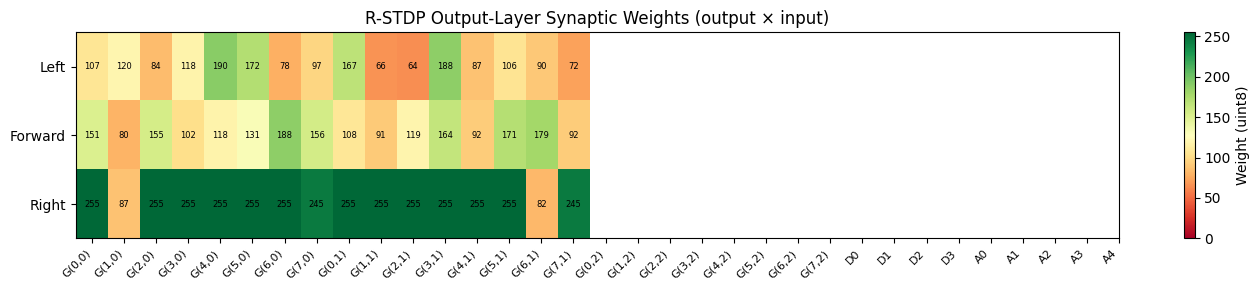

In [44]:
import matplotlib.pyplot as plt

# Visualise output-layer weights of the last trained network
weights = layers[-1].get_weights()  # shape: (n_outputs, n_inputs_to_output_layer)
print("Final output-layer weights (rows=output neurons, cols=inputs):")
print(weights)

# Build input labels depending on whether a hidden layer exists
_best_n_hidden_viz = int(df_tuning_results.sort_values('mean_test_acc', ascending=False).iloc[0]['n_hidden'])
if _best_n_hidden_viz > 0:
    input_labels = [f'H{i}' for i in range(_best_n_hidden_viz)]
else:
    input_labels = [
        'G(0,0)', 'G(1,0)', 'G(2,0)', 'G(3,0)', 'G(4,0)', 'G(5,0)', 'G(6,0)', 'G(7,0)',
        'G(0,1)', 'G(1,1)', 'G(2,1)', 'G(3,1)', 'G(4,1)', 'G(5,1)', 'G(6,1)', 'G(7,1)',
        'G(0,2)', 'G(1,2)', 'G(2,2)', 'G(3,2)', 'G(4,2)', 'G(5,2)', 'G(6,2)', 'G(7,2)',
        'D0', 'D1', 'D2', 'D3',
        'A0', 'A1', 'A2', 'A3', 'A4',
    ]
output_labels = ['Left', 'Forward', 'Right']

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(weights, aspect='auto', cmap='RdYlGn', vmin=0, vmax=255)

ax.set_xticks(range(len(input_labels)))
ax.set_xticklabels(input_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(output_labels)))
ax.set_yticklabels(output_labels)
ax.set_title('R-STDP Output-Layer Synaptic Weights (output × input)')

for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        ax.text(j, i, f'{weights[i,j]:.0f}', ha='center', va='center', fontsize=6)

plt.colorbar(im, ax=ax, label='Weight (uint8)')
plt.tight_layout()
plt.show()

**Output spike tracking**

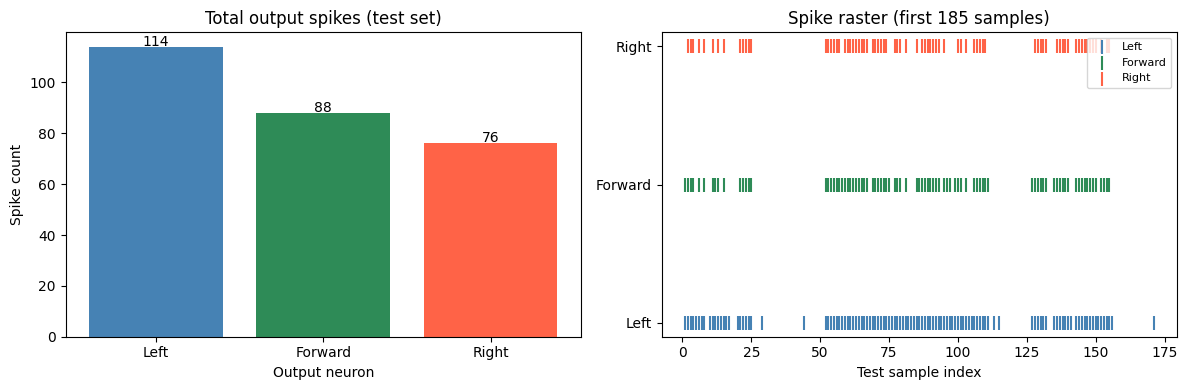

Best config: n_hidden=0, mode=stdp
Spike rate per neuron:
      Left: 114/185 = 0.616
   Forward: 88/185 = 0.476
     Right: 76/185 = 0.411


In [40]:
import importlib
import LIF_SNN_network
importlib.reload(LIF_SNN_network)
from LIF_SNN_network import SNNLayer

# Re-run best config for spike tracking on test set
_best = df_tuning_results.sort_values('mean_test_acc', ascending=False).iloc[0]
best_dopamine_reward = int(_best['dopamine_reward'])
best_dopamine_punish = int(_best['dopamine_punish'])
best_n_hidden        = int(_best['n_hidden'])
best_neuron_params  = {
    "decay":     int(_best['decay']),
    "threshold": int(_best['threshold']),
    "reset":     int(_best['reset']),
}
_w_init = None if pd.isna(_best['w_init']) else int(_best['w_init'])
best_synapse_params = {
    "lr_shift":    int(_best['lr_shift']),
    "w_init":      _w_init,
    "t_pre":       int(_best['t_pre']),
    "t_post":      int(_best['t_post']),
    "tau_e_shift": int(_best['tau_e_shift']),
    "dw_pos":      int(_best['dw_pos']),
    "dw_neg":      int(_best['dw_neg']),
    "w_min":       int(_best['w_min']),
    "w_max":       int(_best['w_max']),
    "mode":        str(_best['mode']),
}

np.random.seed(42)
layers_track = build_network(n_inputs, best_n_hidden, n_outputs,
                             best_neuron_params, best_synapse_params)

# Train for n_epochs
for _ in range(n_epochs):
    reset_all(layers_track)
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):
        layer_outputs = forward_layers(layers_track, current_spikes)
        winner_idx    = layers_track[-1].winner_takes_all(layer_outputs[-1])
        seen, pos = parse_aruco_state(current_spikes, aruco_start, n_aruco)
        dopamine  = reward_signal(seen, pos, winner_idx, best_dopamine_reward, best_dopamine_punish)
        if dopamine != 0:
            apply_reward_all(layers_track, layer_outputs, dopamine)

# --- Test pass: collect per-sample output spikes ---
reset_all(layers_track)
output_labels = ['Left', 'Forward', 'Right']
spike_raster  = []

for current_spikes in test_dataset:
    layer_outputs = forward_layers(layers_track, current_spikes)
    spike_raster.append(layer_outputs[-1])

spike_raster = np.array(spike_raster)   # (n_samples, n_outputs)

# --- Plot 1: total spike counts per output neuron ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = layers_track[-1].spike_count
axes[0].bar(output_labels, counts, color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Total output spikes (test set)')
axes[0].set_ylabel('Spike count')
axes[0].set_xlabel('Output neuron')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# --- Plot 2: spike raster (first 200 samples for readability) ---
n_show = min(200, len(spike_raster))
raster_slice = spike_raster[:n_show]

for neuron_idx in range(n_outputs):
    timesteps = np.where(raster_slice[:, neuron_idx] == 1)[0]
    axes[1].scatter(timesteps, np.full_like(timesteps, neuron_idx),
                    marker='|', s=100, linewidths=1.5,
                    color=['steelblue', 'seagreen', 'tomato'][neuron_idx],
                    label=output_labels[neuron_idx])

axes[1].set_yticks(range(n_outputs))
axes[1].set_yticklabels(output_labels)
axes[1].set_xlabel('Test sample index')
axes[1].set_title(f'Spike raster (first {n_show} samples)')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Spike rate per neuron
print(f"Best config: n_hidden={best_n_hidden}, mode={best_synapse_params['mode']}")
print("Spike rate per neuron:")
for label, count in zip(output_labels, counts):
    print(f"  {label:>8}: {count}/{len(test_dataset)} = {count/len(test_dataset):.3f}")

**Eligibility trace tracking**

Eligibility history shape: (185, 3, 33)  (timesteps × outputs × inputs)


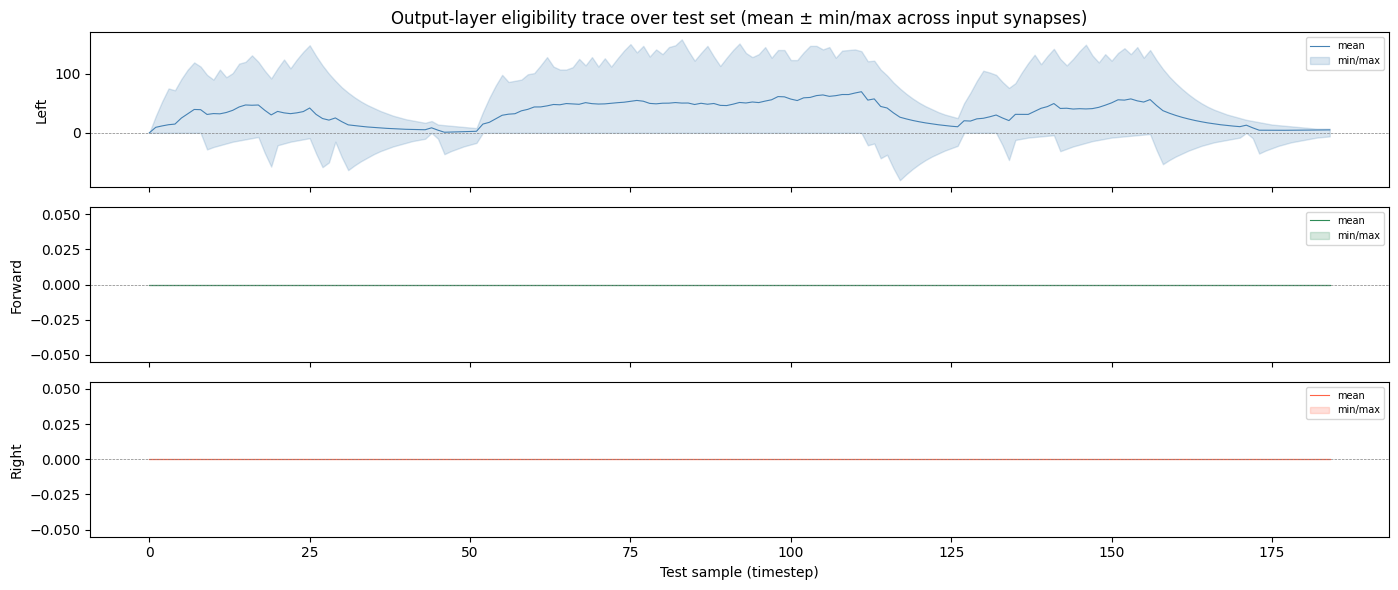

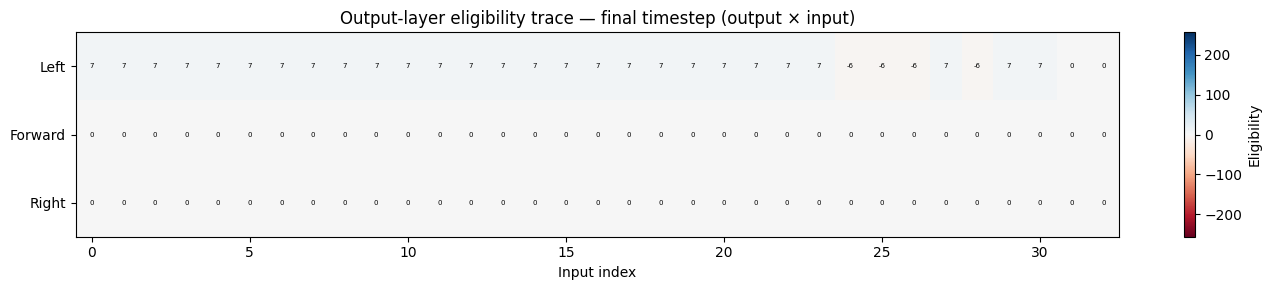

In [41]:
# Re-run best config with eligibility tracking enabled on output layer (test pass only)
np.random.seed(42)
layers_elig = build_network(n_inputs, best_n_hidden, n_outputs,
                            best_neuron_params, best_synapse_params,
                            track_eligibility=True)

# Train without recording history to save memory
layers_elig[-1].track_eligibility = False
for _ in range(n_epochs):
    reset_all(layers_elig)
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):
        layer_outputs = forward_layers(layers_elig, current_spikes)
        winner_idx    = layers_elig[-1].winner_takes_all(layer_outputs[-1])
        seen, pos = parse_aruco_state(current_spikes, aruco_start, n_aruco)
        dopamine  = reward_signal(seen, pos, winner_idx, best_dopamine_reward, best_dopamine_punish)
        if dopamine != 0:
            apply_reward_all(layers_elig, layer_outputs, dopamine)

# Enable tracking for test pass only
layers_elig[-1].track_eligibility = True
reset_all(layers_elig)
for current_spikes in test_dataset:
    forward_layers(layers_elig, current_spikes)

elig_hist = layers_elig[-1].get_eligibility_history()  # (timesteps, n_outputs, n_inputs)
print(f"Eligibility history shape: {elig_hist.shape}  (timesteps × outputs × inputs)")

# --- Plot 1: eligibility over time for each output neuron (mean across inputs) ---
fig, axes = plt.subplots(n_outputs, 1, figsize=(14, 6), sharex=True)
colors = ['steelblue', 'seagreen', 'tomato']
for i, (ax, label, color) in enumerate(zip(axes, output_labels, colors)):
    ax.plot(elig_hist[:, i, :].mean(axis=1), color=color, linewidth=0.8, label='mean')
    ax.fill_between(range(len(elig_hist)),
                    elig_hist[:, i, :].min(axis=1),
                    elig_hist[:, i, :].max(axis=1),
                    alpha=0.2, color=color, label='min/max')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=7)
axes[-1].set_xlabel('Test sample (timestep)')
axes[0].set_title('Output-layer eligibility trace over test set (mean ± min/max across input synapses)')
plt.tight_layout()
plt.show()

# --- Plot 2: heatmap of final eligibility state (n_outputs × n_inputs_to_output) ---
final_elig = elig_hist[-1]

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(final_elig, aspect='auto', cmap='RdBu', vmin=-256, vmax=256)
ax.set_yticks(range(n_outputs))
ax.set_yticklabels(output_labels)
ax.set_xlabel('Input index')
ax.set_title('Output-layer eligibility trace — final timestep (output × input)')
for i in range(final_elig.shape[0]):
    for j in range(final_elig.shape[1]):
        ax.text(j, i, str(final_elig[i, j]), ha='center', va='center', fontsize=5)
plt.colorbar(im, ax=ax, label='Eligibility')
plt.tight_layout()
plt.show()

**Results analysis**

In [42]:
# Load grid search results
df = pd.read_csv("CSV_results/SNN_hyperparameter_Results_hidden.csv")

# Top 25 configurations
top_25 = df.sort_values(by=['mean_test_acc'], ascending=[False]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_test_acc', 'n_hidden', 'decay', 'threshold', 'w_init', 'reset', 'lr_shift', 'mode',
              't_pre', 't_post', 'tau_e_shift', 'dw_pos', 'dw_neg',
              'w_min', 'w_max', 'dopamine_reward', 'dopamine_punish']])

# Parameter impact analysis
print("\n=== Impact of n_hidden on Accuracy ===")
print(df.groupby('n_hidden')['mean_test_acc'].mean())

print("\n=== Impact of mode on Accuracy ===")
print(df.groupby('mode')['mean_test_acc'].mean())

print("\n=== Impact of Decay on Accuracy ===")
print(df.groupby('decay')['mean_test_acc'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('threshold')['mean_test_acc'].mean())

print("\n=== Impact of lr_shift on Accuracy ===")
print(df.groupby('lr_shift')['mean_test_acc'].mean())

print("\n=== Impact of dw_pos on Accuracy ===")
print(df.groupby('dw_pos')['mean_test_acc'].mean())

print("\n=== Impact of dw_neg on Accuracy ===")
print(df.groupby('dw_neg')['mean_test_acc'].mean())

print("\n=== Impact of tau_e_shift on Accuracy ===")
print(df.groupby('tau_e_shift')['mean_test_acc'].mean())

print("\n=== Impact of dopamine_reward on Accuracy ===")
print(df.groupby('dopamine_reward')['mean_test_acc'].mean())

print("\n=== Impact of dopamine_punish on Accuracy ===")
print(df.groupby('dopamine_punish')['mean_test_acc'].mean())

# Best overall
print("\n=== Best Overall Config ===")
best = df.sort_values('mean_test_acc', ascending=False).iloc[0]
print(best)

# Worst overall
print("\n=== Worst Overall Config ===")
worst = df.sort_values('mean_test_acc', ascending=True).iloc[0]
print(worst)

=== Top 25 SNN Configurations ===
    mean_test_acc  n_hidden  decay  threshold  w_init  reset  lr_shift   mode  \
21       0.528649         0     64       1024     NaN      0         3   stdp   
17       0.456216        16     64       1024     NaN      0         3   stdp   
23       0.421622        16     64       1024     NaN      0         3   stdp   
28       0.420541         8    128        512     NaN      0         3   stdp   
29       0.417297        16    128        512     NaN      0         3   stdp   
39       0.387027         0    128       1024     NaN      0         3   stdp   
43       0.378378         8    128       1024     NaN      0         3  rstdp   
34       0.377297         8    128        512     NaN      0         3   stdp   
9        0.372973         0     64        512     NaN      0         3   stdp   
35       0.370811        16    128        512     NaN      0         3   stdp   
33       0.369730         0    128        512     NaN      0         3   st

/tmp/ipykernel_6980/1544872596.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(hidden_groups, labels=labels)


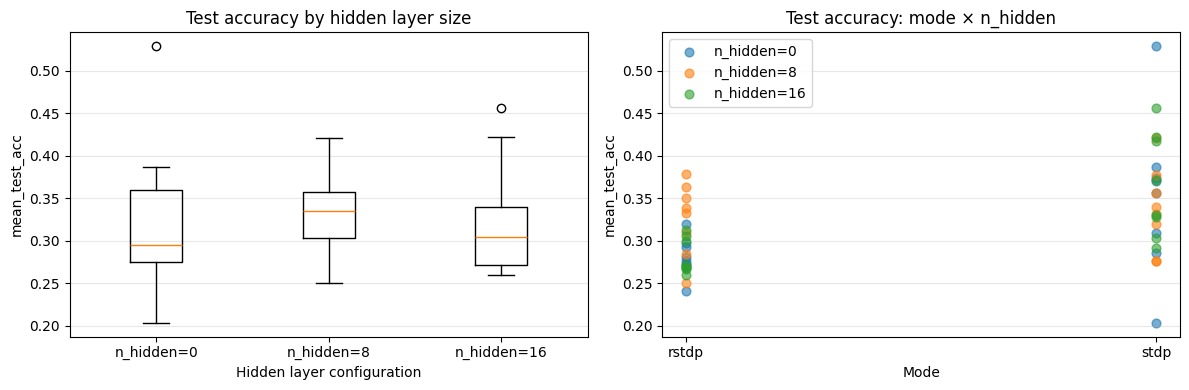

In [43]:
# Visual comparison: accuracy distribution by n_hidden
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot of test accuracy per n_hidden
hidden_groups = [df[df['n_hidden'] == h]['mean_test_acc'].values
                 for h in sorted(df['n_hidden'].unique())]
labels = [f'n_hidden={int(h)}' for h in sorted(df['n_hidden'].unique())]

axes[0].boxplot(hidden_groups, labels=labels)
axes[0].set_title('Test accuracy by hidden layer size')
axes[0].set_ylabel('mean_test_acc')
axes[0].set_xlabel('Hidden layer configuration')
axes[0].grid(axis='y', alpha=0.3)

# Box plot of test accuracy per mode, split by n_hidden
for h in sorted(df['n_hidden'].unique()):
    subset = df[df['n_hidden'] == h]
    axes[1].scatter(subset['mode'], subset['mean_test_acc'],
                    label=f'n_hidden={int(h)}', alpha=0.6, s=40)
axes[1].set_title('Test accuracy: mode × n_hidden')
axes[1].set_ylabel('mean_test_acc')
axes[1].set_xlabel('Mode')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()